In [1]:
# --- Install All in One Go ---
%pip install numpy tensorflow scikit-learn matplotlib pandas

  Using cached protobuf-5.29.4-cp310-abi3-win_amd64.whl (434 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
  Attempting uninstall: tensorboard-data-server
    Found existing installation: tensorboard-data-server 0.6.1
    Uninstalling tensorboard-data-server-0.6.1:
      Successfully uninstalled tensorboard-data-server-0.6.1
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.6
    Uninstalling protobuf-3.19.6:
      Successfully uninstalled protobuf-3.19.6
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [2]:
dataset = 'keypoint_classifier/keypoint.csv'
# dataset = '/kaggle/input/mediapip4/keypoint.csv'
model_save_path = 'keypoint_classifier.keras'

In [3]:
NUM_CLASSES = 26

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │           286 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356 (5.30 KB)

 Trainable params: 1,356 (5.30 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)

es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 11s 783ms/step - accuracy: 0.0703 - loss: 3.2761
Epoch 1: saving model to keypoint_classifier.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0452 - loss: 3.2676 - val_accuracy: 0.0148 - val_loss: 3.2423
Epoch 2/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0469 - loss: 3.2356
Epoch 2: saving model to keypoint_classifier.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0521 - loss: 3.2432 - val_accuracy: 0.0828 - val_loss: 3.2218
Epoch 3/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0547 - loss: 3.2245
Epoch 3: saving model to keypoint_classifier.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0629 - loss: 3.2216 - val_accuracy: 0.0784 - val_loss: 3.1899
Epoch 4/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1094 - loss: 3.2081
Epoch 4: saving model to keypoint_classifier.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0757 - loss: 3.1918 - val_accuracy: 0.0902 - 

In [12]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8428 - loss: 0.6138 


In [13]:
model = tf.keras.models.load_model(model_save_path)

In [14]:
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[6.13419616e-05 1.02691455e-02 3.21771717e-04 6.82613105e-02
 4.49898560e-03 1.19140130e-02 2.14427849e-03 2.30863108e-03
 9.97608760e-04 1.81378027e-07 1.65693685e-01 2.69054231e-04
 8.93863544e-05 4.78758338e-05 1.39249241e-04 8.07616743e-04
 7.12670317e-06 2.72134274e-01 7.37846538e-04 2.23725183e-05
 1.28442660e-01 3.12855363e-01 1.70639083e-02 8.72762699e-04
 3.92242000e-05 2.96636273e-07]
21


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


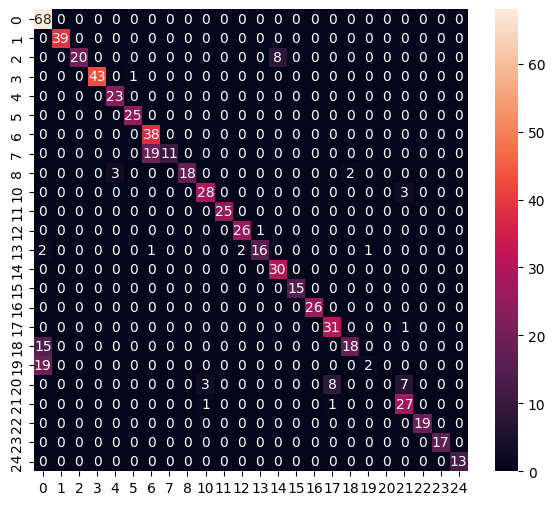

Classification Report
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        68
           1       1.00      1.00      1.00        39
           2       1.00      0.71      0.83        28
           3       1.00      0.98      0.99        44
           4       0.88      1.00      0.94        23
           5       0.96      1.00      0.98        25
           6       0.66      1.00      0.79        38
           7       1.00      0.37      0.54        30
           8       1.00      0.78      0.88        23
          10       0.88      0.90      0.89        31
          11       1.00      1.00      1.00        25
          12       0.93      0.96      0.95        27
          13       0.94      0.73      0.82        22
          14       0.79      1.00      0.88        30
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00        26
          17       0.78      0.97      0.86        32
     

c:\Users\Reetam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Reetam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Reetam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

In [16]:
model.save(model_save_path, include_optimizer=False)

In [17]:
# tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'
tflite_save_path = 'keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Reetam\AppData\Local\Temp\tmphtgn0rqw\assets


INFO:tensorflow:Assets written to: C:\Users\Reetam\AppData\Local\Temp\tmphtgn0rqw\assets


Saved artifact at 'C:\Users\Reetam\AppData\Local\Temp\tmphtgn0rqw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  2842550648000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2842544433360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2842544437408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2842550745072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2842550739088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2842550744896: TensorSpec(shape=(), dtype=tf.resource, name=None)


7524

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\Reetam\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


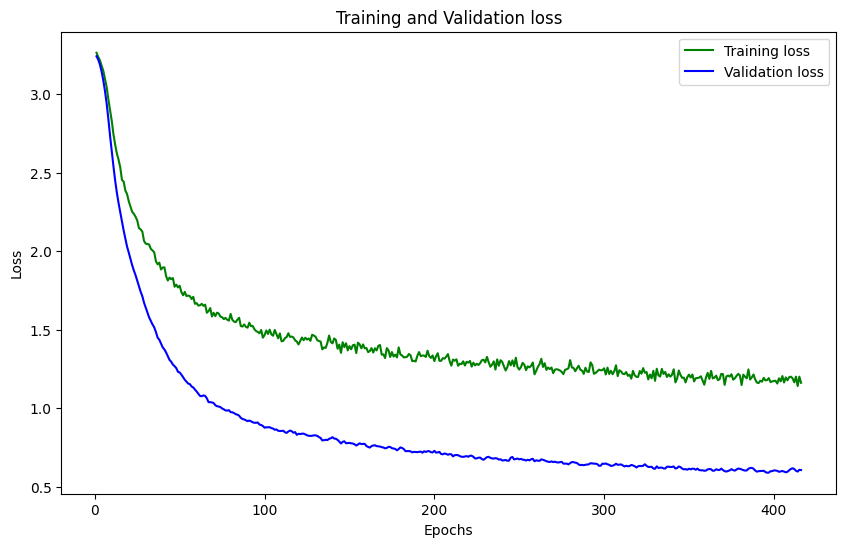

In [19]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1, len(loss_train) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

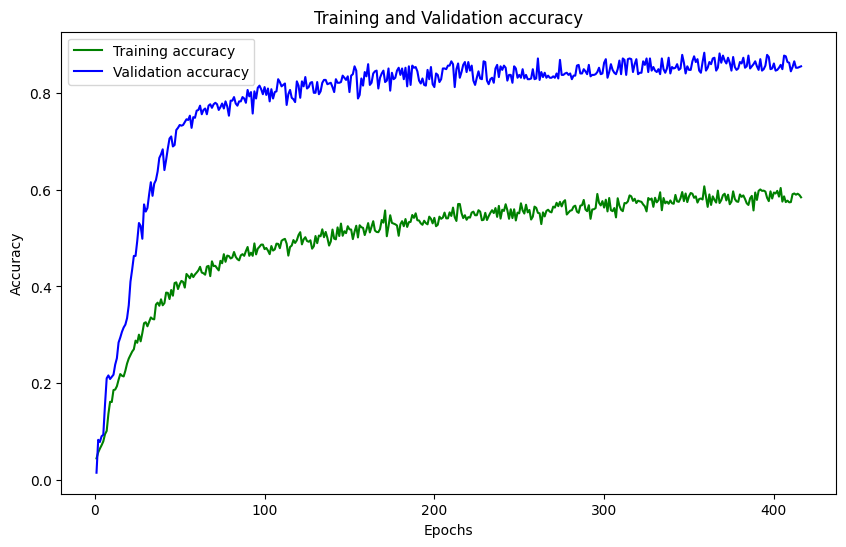

In [20]:
acc_train = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1, len(acc_train) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc_train, 'g', label='Training accuracy')
plt.plot(epochs, acc_val, 'b', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()